In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from factor_analyzer import FactorAnalyzer
from sklearn.linear_model import Lasso

# rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1

In [3]:
# df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/data/pandora_to_big5_v4.csv')
df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/data/pandora_to_big5_main.csv')
df.shape, df.columns

/tmp/ipykernel_2009340/3760893616.py:3: DtypeWarning: Columns (18,25,26,27,35,41,42,43,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/data/pandora_to_big5_main.csv')


(935102, 55)

In [6]:
v4_df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/data/pandora_to_big5_v4.csv')
v4_df.shape

(935102, 8)

In [5]:
liwc_df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/processed_data/LIWC_pandora_to_big5_v4.csv')
liwc_df.shape

(908432, 140)

In [2]:
summary_variables = ["Segment", "WC", "Analytic", "Clout", "Authentic", "Tone", "WPS", "BigWords", "Dic"]
linguistic_dimensions = ["Linguistic", "function", "pronoun", "ppron", "i", "we", "you", "shehe", "they", "ipron", "det", "article", "number", "prep", "auxverb", "adverb", "conj", "negate", "verb", "adj", "quantity"]
psychological_process = ["Drives", "affiliation", "achieve", "power", "Cognition", "allnone", "cogproc", "insight", "cause", "discrep", "tentat", "certitude", "differ", "memory", "Affect", "tone_pos", "tone_neg", "emotion", "emo_pos", "emo_neg", "emo_anx", "emo_anger", "emo_sad", "swear", "Social", "socbehav", "prosocial", "polite", "conflict", "moral", "comm", "socrefs", "family", "friend", "female", "male"]
expanded_dictionary =  ["Culture", "politic", "ethnicity", "tech", "Lifestyle", "leisure", "home", "work", "money", "relig", "Physical", "health", "illness", "wellness", "mental", "substances", "sexual", "food", "death", "need", "want", "acquire", "lack", "fulfill", "fatigue", "reward", "risk", "curiosity", "allure", "Perception", "attention", "motion", "space", "visual", "auditory", "feeling", "time", "focuspast", "focuspresent", "focusfuture", "Conversation", "netspeak", "assent", "nonflu", "filler",  "AllPunc", "Period", "Comma", "QMark", "Exclam", "Apostro", "OtherP", "Emoji"]
emotions = [ "anger", "anticipation", "disgust", "fear", "joy", "negative", "positive", "sadness", "surprise", "trust"]
VAD = ["Valence", "Arousal", "Dominance", "sent_score"]

In [22]:
ldf = pd.read_csv(f'data/cOPN_ldf.csv')
columns = set(ldf.columns)
columns.remove("Unnamed: 0")

for c in ldf.columns:
    if c in ['Unnamed: 0']: continue
    if c in ["Valence", "Arousal", "Dominance", "sent_score"]: continue

    print(f'"{c}"', end=", ")
    if c == 'Dic': print (']')
    if c == 'quantity': print ()
    if c == 'male': print()


"Segment", "WC", "Analytic", "Clout", "Authentic", "Tone", "WPS", "BigWords", "Dic", 
"Linguistic", "function", "pronoun", "ppron", "i", "we", "you", "shehe", "they", "ipron", "det", "article", "number", "prep", "auxverb", "adverb", "conj", "negate", "verb", "adj", "quantity", 
"Drives", "affiliation", "achieve", "power", "Cognition", "allnone", "cogproc", "insight", "cause", "discrep", "tentat", "certitude", "differ", "memory", "Affect", "tone_pos", "tone_neg", "emotion", "emo_pos", "emo_neg", "emo_anx", "emo_anger", "emo_sad", "swear", "Social", "socbehav", "prosocial", "polite", "conflict", "moral", "comm", "socrefs", "family", "friend", "female", "male", 
"Culture", "politic", "ethnicity", "tech", "Lifestyle", "leisure", "home", "work", "money", "relig", "Physical", "health", "illness", "wellness", "mental", "substances", "sexual", "food", "death", "need", "want", "acquire", "lack", "fulfill", "fatigue", "reward", "risk", "curiosity", "allure", "Perception", "attention", "motion", 

In [3]:
traits = {
    'cOPN': 'Openness',
    'cEXT': 'Extraversion',
    'cNEU': 'Neuroticism',
    'cAGR': 'Agreeableness',	
    'cCON': 'Conscientiousness'
}
pca_map = {
    'cOPN': 2,
    'cEXT': 2,
    'cNEU': 4,
    'cAGR': 3,
    'cCON': 2
}

trait_features ={}

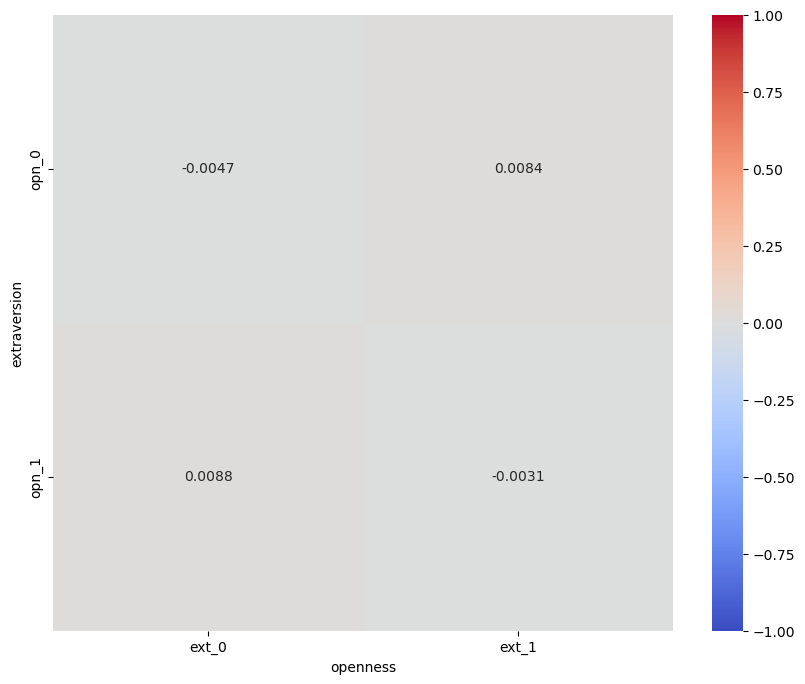

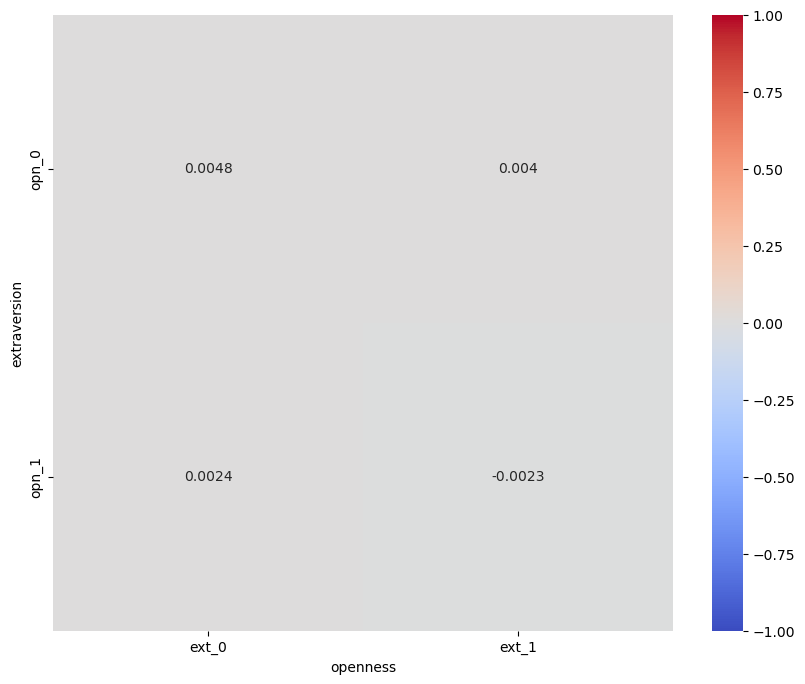

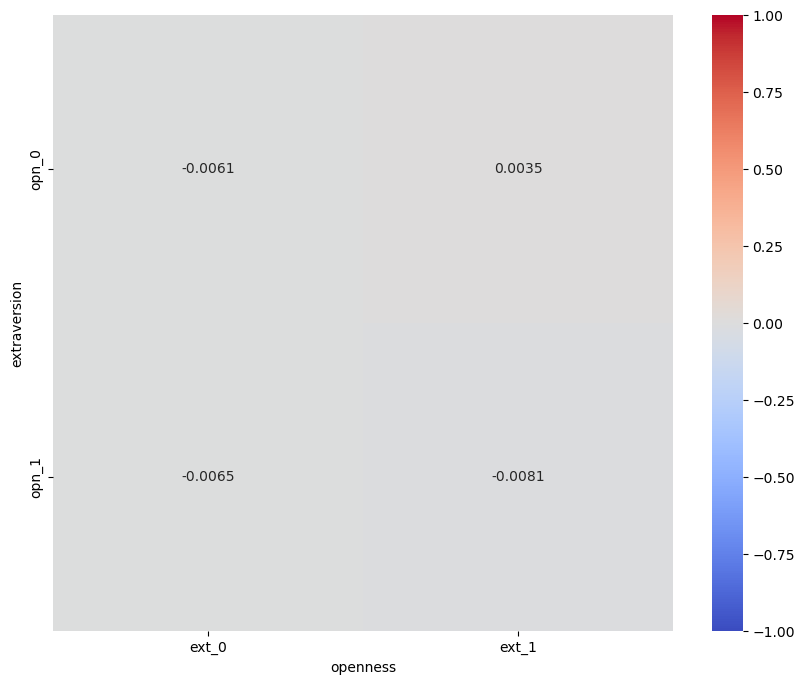

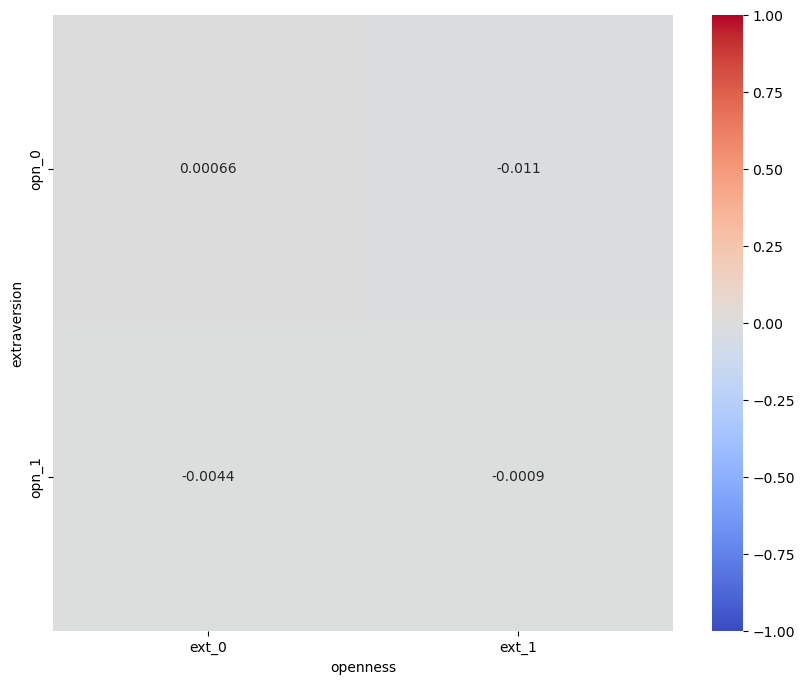

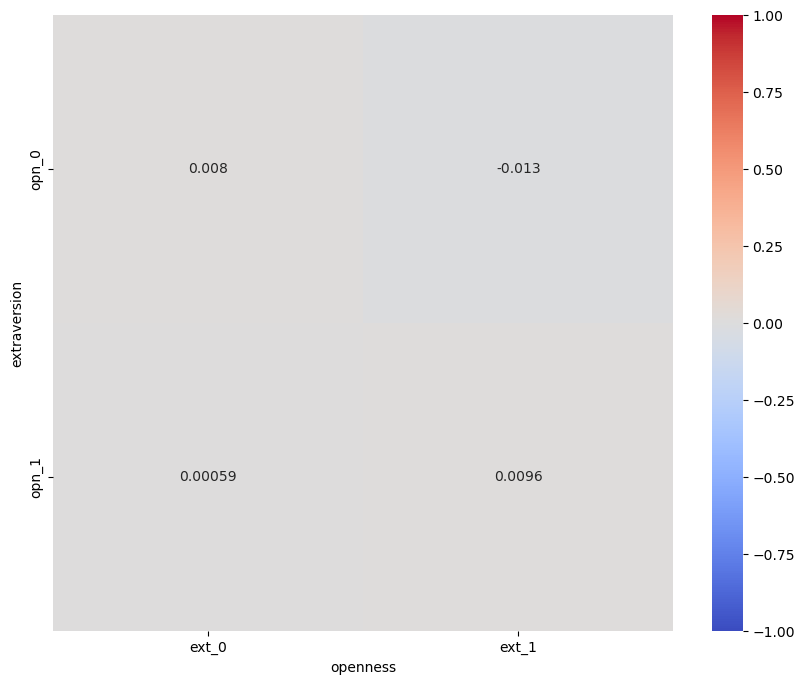

In [34]:
pca_dim = 2
pca_dim1 = 2
savefig = True
trait1 = 'cEXT'
trait2 ='cNEU'
t_list = ['cOPN', 'cEXT', 'cNEU', 'cAGR', 'cCON']
for i, t in enumerate(t_list):
    trait1 = t_list[i]
    trait2 = t_list[0] if i+1 > 4 else t_list[i+1]
    _opn = np.load(f'data/{trait1}_emb.npy') 
    _ext = np.load(f'data/{trait2}_emb.npy') 
    opn_df = pd.DataFrame(_opn)
    ext_df = pd.DataFrame(_ext)

    opn_df.columns = [f'e_{i}' for i in range(1536)]
    ext_df.columns = [f'e_{i}' for i in range(1536)]

    pca = PCA(n_components=pca_dim)
    re = pca.fit_transform(opn_df)
    odf = pd.DataFrame(re)
    odf.columns = [f'opn_{i}' for i in range(odf.shape[1])]

    pca = PCA(n_components=pca_dim1)
    re = pca.fit_transform(ext_df)
    edf = pd.DataFrame(re)
    edf.columns = [f'ext_{i}' for i in range(edf.shape[1])]

    final_df = pd.concat([odf, edf], axis=1)
    # correlation_matrix = odf.corr(edf, method='pearson')

    correlation_matrix = final_df.corr(method='pearson') 
    embedding_liwc_corr = correlation_matrix.loc[odf.columns, edf.columns]

    plt.figure(figsize=(10, 8))
    sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    # sns.heatmap(embedding_liwc_corr, annot=True, cmap='RdBu', vmin=-1, vmax=1)

    plt.xlabel(f'openness')
    plt.ylabel(f'extraversion')
    # if savefig: plt.savefig(f'corre/{target}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# pca_dim = 3
# lasso_alpha = 0.3
# savefig = True

# for target in traits:
#     ldf = pd.read_csv(f'data/{target}_ldf.csv')
#     emb_np = np.load(f'data/{target}_emb.npy') 
#     eedf = pd.DataFrame(emb_np)
#     eedf.columns = [f'e_{i}' for i in range(1536)]

#     scaler = StandardScaler()
#     esdf = scaler.fit_transform(eedf)
#     lsdf = scaler.fit_transform(ldf)
#     print(eedf.shape, ldf.shape, target)

#     pca = PCA(n_components=pca_map[target])
#     re = pca.fit_transform(esdf)
#     redf = pd.DataFrame(re)
#     redf.columns = [f'pca_{i}' for i in range(redf.shape[1])]
#     X = np.array(lsdf)  
#     y = np.array(redf)  
#     lasso = Lasso(alpha=lasso_alpha)  
#     lasso.fit(X, y[:, 0])  
#     coefficients = lasso.coef_
#     key_features = []

#     for i in range(y.shape[1]):
#         lasso = Lasso(alpha=lasso_alpha) 
#         lasso.fit(X, y[:, i])
#         coefficients = lasso.coef_
#         key_features.append(coefficients)

#     liwc_feature_names = ldf.columns

#     # Assuming `coefficients` is the array of Lasso coefficients
#     highly_important_indices = np.where(np.abs(coefficients) != 0)[0]
#     highly_important_features = [liwc_feature_names[i] for i in highly_important_indices]
#     print("Highly Important LIWC Features:", highly_important_features)

#     plt.figure(figsize=(10, 5))
#     plt.bar(range(len(highly_important_indices)), coefficients[highly_important_indices])
#     plt.xticks(range(len(highly_important_indices)), [liwc_feature_names[i] for i in highly_important_indices], rotation=90)
#     plt.xlabel("LIWC Features")
#     plt.ylabel("Coefficient Value")
#     # plt.title(f"{traits[target]}: Highly Important LIWC Features (Lasso Coefficients)")
#     # plt.title(f'{traits[target]}')
#     if savefig: plt.savefig(f'corre/{target}_liwc.png', bbox_inches='tight')
#     plt.show()

#     # pca = PCA(n_components=None)
#     # pca.fit(ldf[highly_important_features])
#     # plt.plot(pca.explained_variance_ratio_, marker='o')
#     # plt.xlabel('Principal Component')
#     # plt.ylabel('Explained Variance Ratio')
#     # plt.title('Scree Plot')
#     # if savefig: plt.savefig(f'corre/{target}_stree.png', bbox_inches='tight')
#     # plt.show()

#     # highly_important_features = summary_variables
#     final_df = pd.concat([ldf[trait_features[tar]], redf], axis=1)
#     # Compute correlation matrix
#     correlation_matrix = final_df.corr(method='pearson') 
#     embedding_liwc_corr = correlation_matrix.loc[highly_important_features, redf.columns]


#     plt.figure(figsize=(10, 8))
#     sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
#     # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
#     # plt.title(f'{traits[target]}')
#     plt.xlabel(f'Principal Components')
#     plt.ylabel(f'Important LIWC Features')
#     if savefig: plt.savefig(f'corre/{target}.png', bbox_inches='tight')
#     plt.show()

(20333, 1536) (20333, 134) cOPN


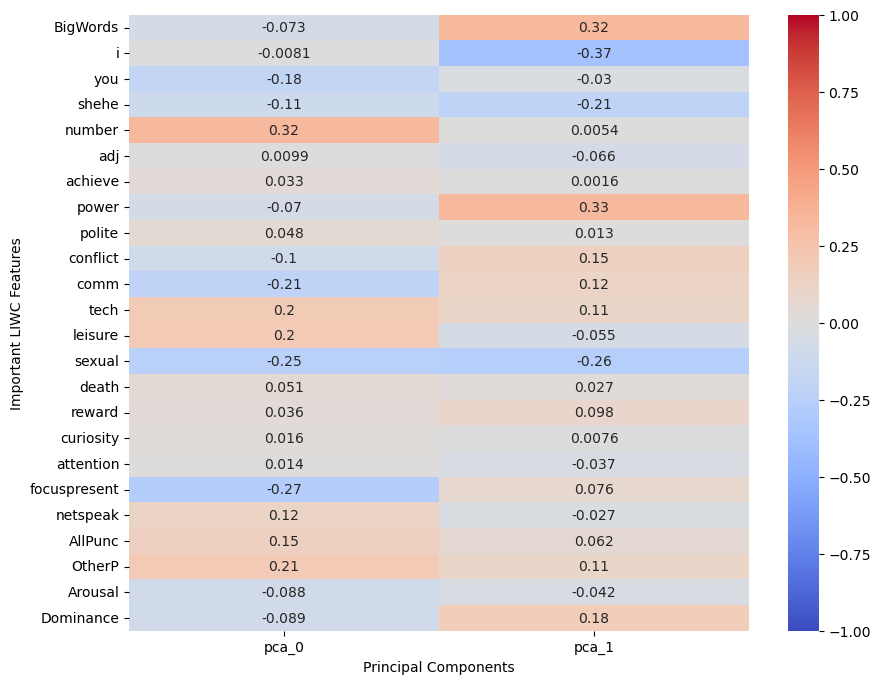

(24026, 1536) (24026, 134) cEXT


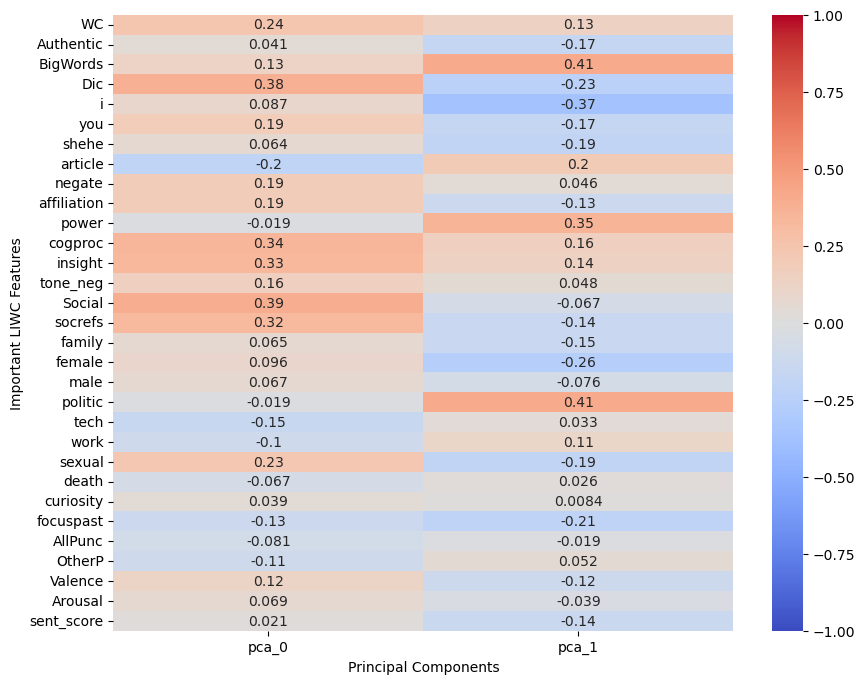

(19952, 1536) (19952, 134) cNEU


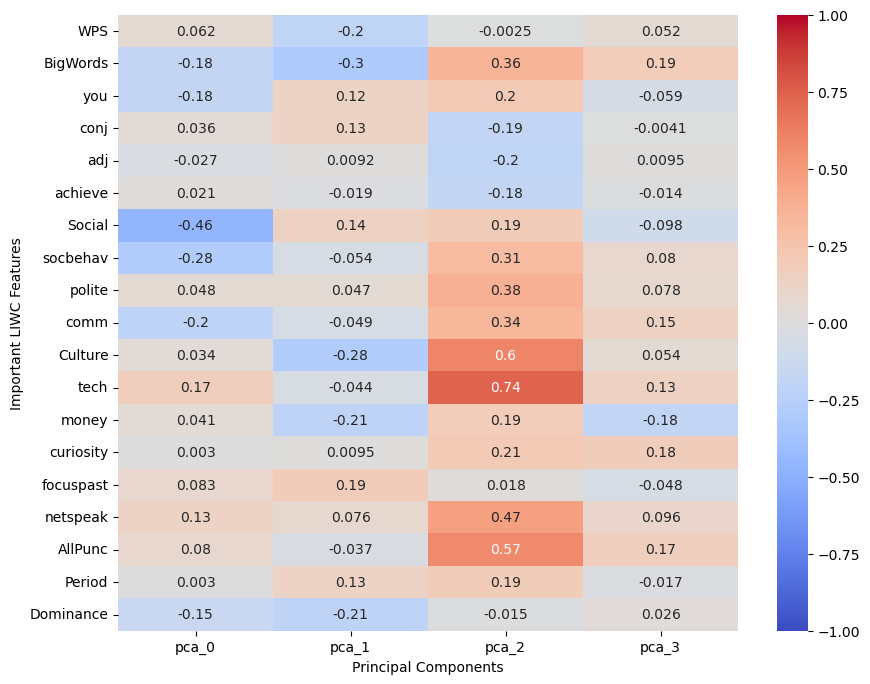

(19830, 1536) (19830, 134) cAGR


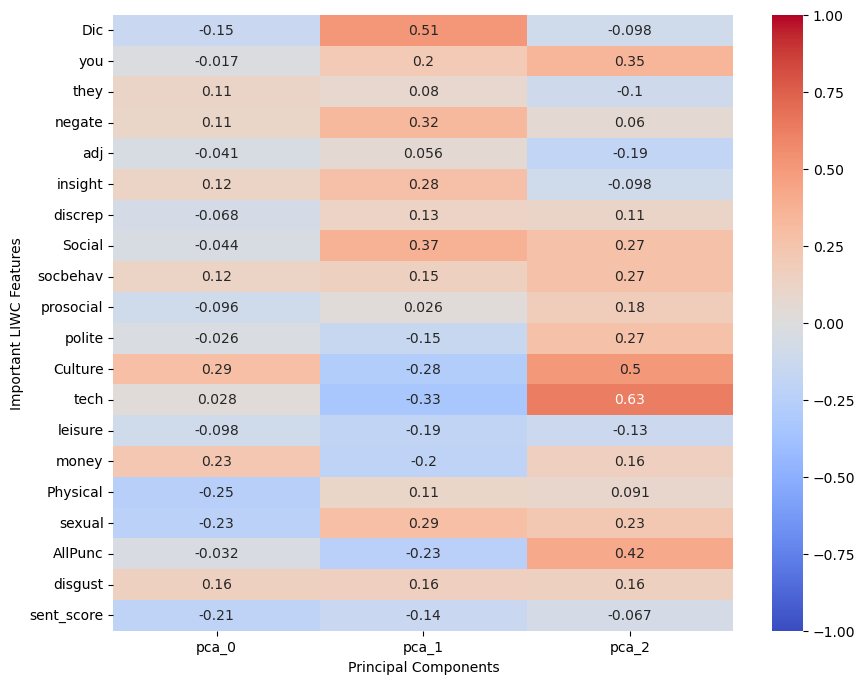

(24591, 1536) (24591, 134) cCON


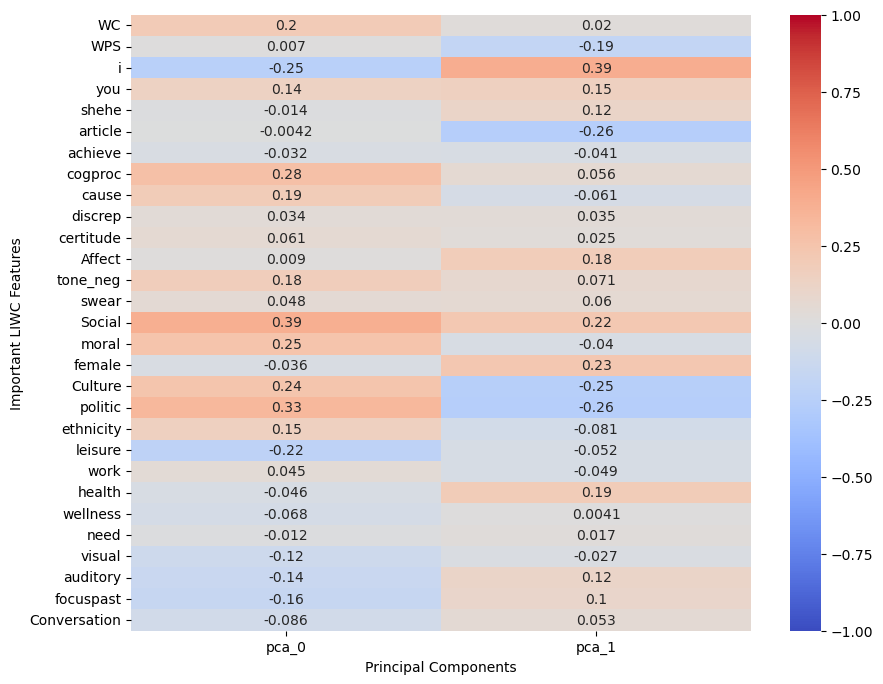

In [50]:
pca_dim = 3
lasso_alpha = 0.3
savefig = True

for target in traits:
    ldf = pd.read_csv(f'data/{target}_ldf.csv')
    emb_np = np.load(f'data/{target}_emb.npy') 
    eedf = pd.DataFrame(emb_np)
    eedf.columns = [f'e_{i}' for i in range(1536)]

    scaler = StandardScaler()
    esdf = scaler.fit_transform(eedf)
    lsdf = scaler.fit_transform(ldf)
    print(eedf.shape, ldf.shape, target)

    pca = PCA(n_components=pca_map[target])
    re = pca.fit_transform(esdf)
    redf = pd.DataFrame(re)
    redf.columns = [f'pca_{i}' for i in range(redf.shape[1])]

    highly_important_features = trait_features[target]
    final_df = pd.concat([ldf[highly_important_features], redf], axis=1)
    # Compute correlation matrix
    correlation_matrix = final_df.corr(method='pearson') 
    embedding_liwc_corr = correlation_matrix.loc[highly_important_features, redf.columns]


    plt.figure(figsize=(10, 8))
    sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
    # plt.title(f'{traits[target]}')
    plt.xlabel(f'Principal Components')
    plt.ylabel(f'Important LIWC Features')
    if savefig: plt.savefig(f'corre/{target}.png', bbox_inches='tight')
    plt.show()

In [16]:
dimensions = {
'summary_variables' : [ "WC", "Analytic", "Clout", "Authentic", "Tone", "WPS", "BigWords", "Dic"],
'linguistic_dimensions' : ["Linguistic", "function", "pronoun", "ppron", "i", "we", "you", "shehe", "they", "ipron", "det", "article", "number", "prep", "auxverb", "adverb", "conj", "negate", "verb", "adj", "quantity"],
'psychological_process' :  ["Drives", "affiliation", "achieve", "power", "Cognition", "allnone", "cogproc", "insight", "cause", "discrep", "tentat", "certitude", "differ", "memory", "Affect", "tone_pos", "tone_neg", "emotion", "emo_pos", "emo_neg", "emo_anx", "emo_anger", "emo_sad", "swear", "Social", "socbehav", "prosocial", "polite", "conflict", "moral", "comm", "socrefs", "family", "friend", "female", "male"],
'expanded_dictionary' :  ["Culture", "politic", "ethnicity", "tech", "Lifestyle", "leisure", "home", "work", "money", "relig", "Physical", "health", "illness", "wellness", "mental", "substances", "sexual", "food", "death", "need", "want", "acquire", "lack", "fulfill", "fatigue", "reward", "risk", "curiosity", "allure", "Perception", "attention", "motion", "space", "visual", "auditory", "feeling", "time", "focuspast", "focuspresent", "focusfuture", "Conversation", "netspeak", "assent", "nonflu", "filler",  "AllPunc", "Period", "Comma", "QMark", "Exclam", "Apostro", "OtherP", "Emoji"],
'emotions' : [ "anger", "anticipation", "disgust", "fear", "joy", "negative", "positive", "sadness", "surprise", "trust"],
'VAD' : ["Valence", "Arousal", "Dominance", "sent_score"]
}

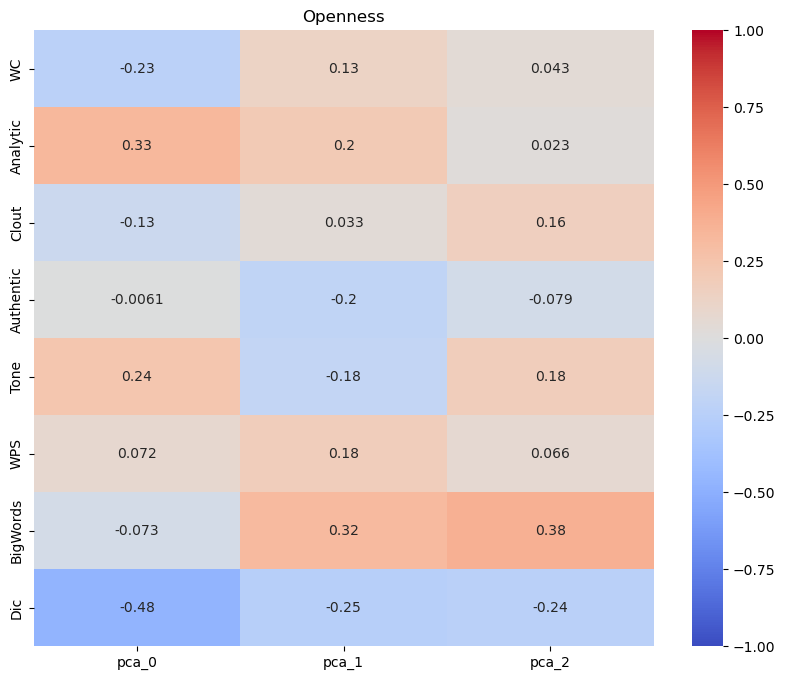

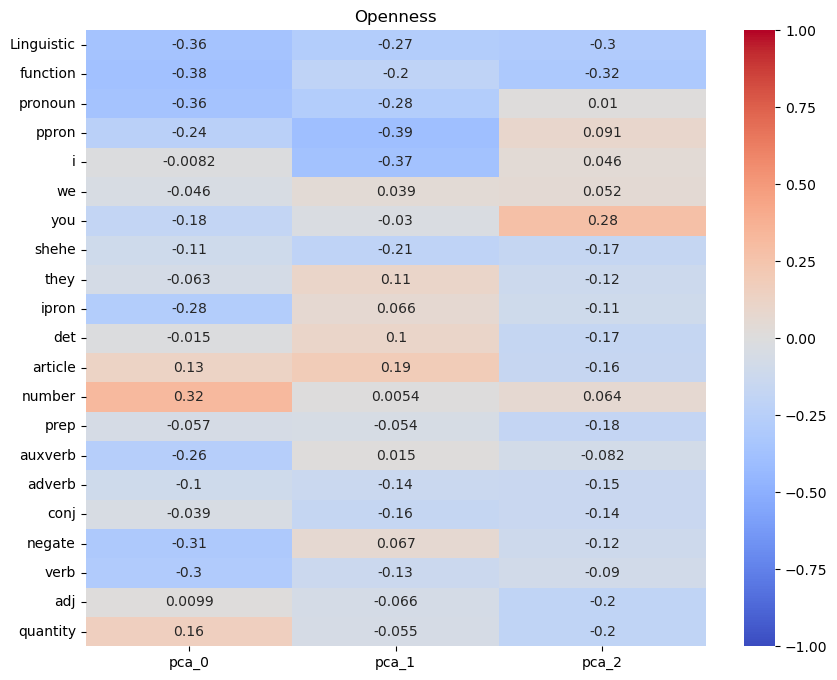

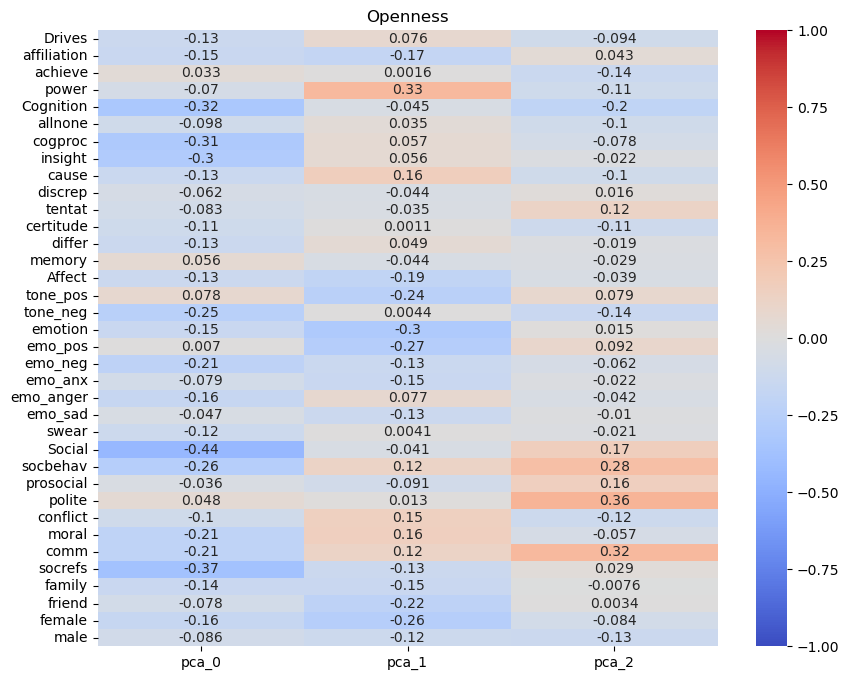

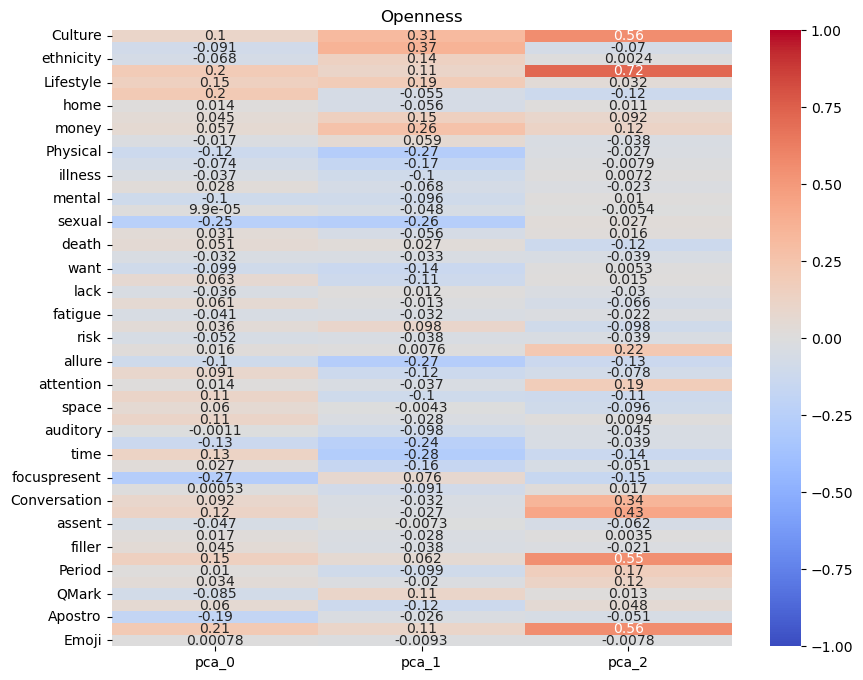

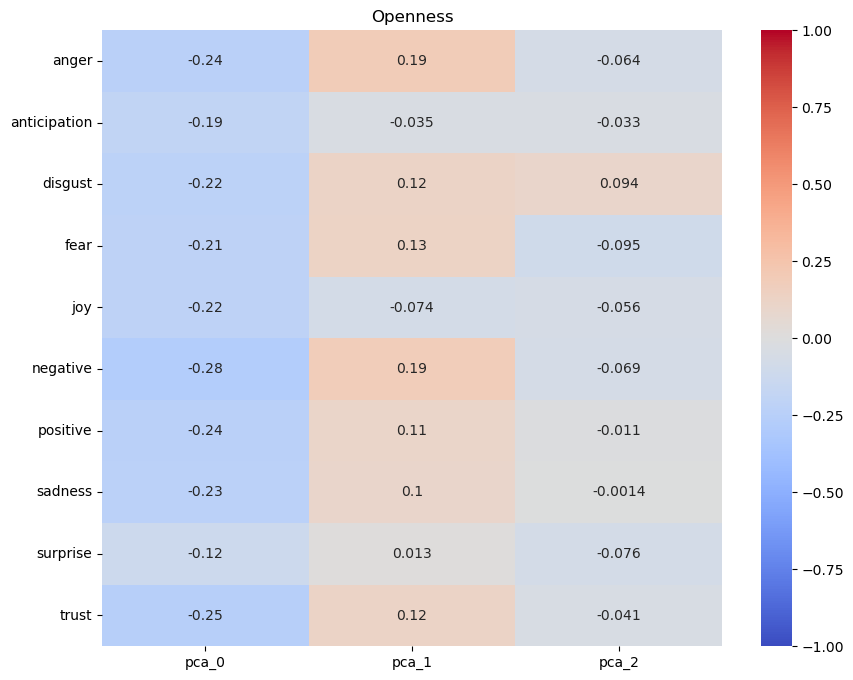

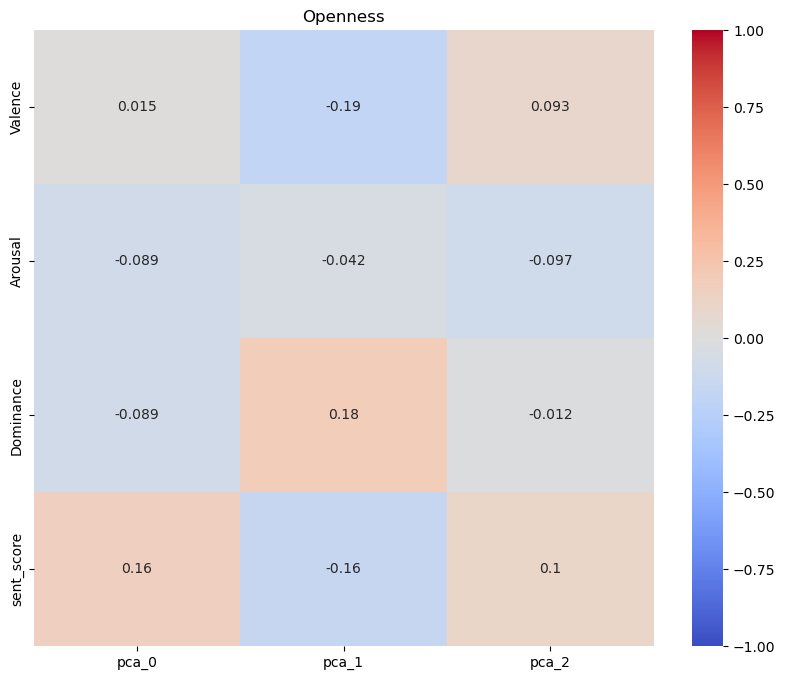

In [17]:
for v in dimensions.values():
    highly_important_features = v
    final_df = pd.concat([ldf[highly_important_features], redf], axis=1)
    # Compute correlation matrix
    correlation_matrix = final_df.corr(method='pearson') 
    embedding_liwc_corr = correlation_matrix.loc[highly_important_features, redf.columns]


    plt.figure(figsize=(10, 8))
    sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
    plt.title(f'{traits[target]}')
    if savefig: plt.savefig(f'output/{target}.png', bbox_inches='tight')
    plt.show()